<a href="https://colab.research.google.com/github/anandamel/AI_dependency_Prediction/blob/main/AI_Dependency_Prediction_Machine_Learning_Projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import lib

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.8 MB/s eta 0:00:00


In [ ]:
import textwrap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

### **Load data**

import data from kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import os
# HOME = '/content/drive/MyDrive/Data Project Portfolio/AIDependency'
# print(HOME)

/content/drive/MyDrive/Data Project Portfolio/AIDependency


In [ ]:
# !kaggle datasets download -d sridipbasu/ai-depndency-career-anxiety-and-student-burnout

Dataset URL: https://www.kaggle.com/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout
License(s): MIT
100% 437k/437k [00:00<00:00, 28.9MB/s]



In [ ]:
# !unzip -qq /content/drive/MyDrive/DataProjectPortfolio/AIDependency/datasets/ai-depndency-career-anxiety-and-student-burnout.zip -d /content/drive/MyDrive/DataProjectPortfolio/AIDependency/datasets

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DataProjectPortfolio/AIDependency/datasets/ai_dependency_career_anxiety_students.csv')

In [ ]:
data

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,STU_14996,21,Female,B.Sc/B.A/B.Com,CS/IT,1,Tier 3,Urban,2.8,ChatGPT,...,0.0,6.2,2,0.2,9.6,4,6,2,0.0,7.02
14996,STU_14997,22,Male,B.Tech/B.E.,Commerce/Management,4,Tier 1,Urban,3.6,ChatGPT,...,6.1,11.7,3,2.9,5.8,5,3,9,1.0,7.31
14997,STU_14998,22,Male,B.Tech/B.E.,CS/IT,2,Tier 1,Rural,1.7,Gemini,...,6.3,17.2,5,0.6,7.4,3,1,9,0.0,8.65
14998,STU_14999,22,Female,MBA,CS/IT,2,Tier 2,Urban,0.0,NaN,...,0.8,0.0,1,2.0,9.1,5,6,2,0.0,4.97


In [ ]:
data.shape

(15000, 30)

### **Memeriksa Tipe Variabel dan Jumlahnya**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       15000 non-null  object 
 1   age                              15000 non-null  int64  
 2   gender                           15000 non-null  object 
 3   degree_type                      15000 non-null  object 
 4   stream                           15000 non-null  object 
 5   year_of_study                    15000 non-null  int64  
 6   college_tier                     15000 non-null  object 
 7   urban_or_rural                   15000 non-null  object 
 8   daily_ai_tool_usage_hrs          15000 non-null  float64
 9   primary_ai_tools_used            11785 non-null  object 
 10  uses_ai_for_assignments          15000 non-null  object 
 11  ai_replaces_own_thinking_score   15000 non-null  int64  
 12  ai_dependency_scor

Terlihat 8 fitur bertipe data object, 7 fitur bertipe data float64, dan 15 fitur bertipe data int64

In [ ]:
data.describe(include='all')

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,15000,15000.000000,15000,15000,15000,15000.000000,15000,15000,15000.000000,11785,...,15000.000000,14767.000000,15000.0000,14790.000000,14797.000000,15000.000000,15000.000000,15000.000000,14780.000000,15000.000000
unique,15000,NaN,3,4,4,NaN,3,2,NaN,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,STU_15000,NaN,Male,B.Tech/B.E.,CS/IT,NaN,Tier 3,Urban,NaN,ChatGPT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,7840,6700,6091,NaN,7475,10282,NaN,5469,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,21.384533,NaN,NaN,NaN,2.100067,NaN,NaN,2.013893,NaN,...,2.730660,6.304612,2.0326,3.006437,6.993364,4.771133,5.472600,4.319733,0.285792,5.998019
std,NaN,2.005626,NaN,NaN,NaN,0.987650,NaN,NaN,1.735977,NaN,...,1.801026,5.553880,1.8095,1.649033,1.004809,1.778210,2.068317,2.151266,0.451806,1.593982
min,NaN,18.000000,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,NaN,...,0.000000,0.000000,0.0000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,NaN,20.000000,NaN,NaN,NaN,1.000000,NaN,NaN,0.400000,NaN,...,1.300000,1.000000,1.0000,1.800000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,NaN,21.000000,NaN,NaN,NaN,2.000000,NaN,NaN,1.800000,NaN,...,2.600000,5.500000,2.0000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,6.000000
75%,NaN,22.000000,NaN,NaN,NaN,3.000000,NaN,NaN,3.200000,NaN,...,4.000000,10.100000,3.0000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000


### **Data Cleaning**

In [ ]:
pd.DataFrame({
    'Missing Values' : data.isna().sum(),
    'Percentage' : data.isna().sum()/data.shape[0]*100
  })

,Missing Values,Percentage
student_id,0,0.000000
age,0,0.000000
gender,0,0.000000
degree_type,0,0.000000
stream,0,0.000000
year_of_study,0,0.000000
college_tier,0,0.000000
urban_or_rural,0,0.000000
daily_ai_tool_usage_hrs,0,0.000000
primary_ai_tools_used,3215,21.433333


terlihat kolom yang punya null values antara lain  

*   `primary_ai_tools_used` -> **3215** kolom dgn persentase **21,43%**
*   `self_learning_hours_per_week `-> **233** kolom dgn persentase **1.5%**


*   `social_media_hrs_per_day` -> **210** kolom dgn persentase **1.4%**
*   `sleep_hours` -> **203** kolom dgn persentase **1.3%**


*   `seeks_career_counseling` -> **220** kolom dgn persentase **1.4%**




  

karena cukup besar dan representatif, jadi kolomnya di drop saja

In [ ]:
df_clean = data.dropna()
pd.DataFrame({
    'Missing Values' : df_clean.isna().sum(),
    'Percentage' : df_clean.isna().sum()/df_clean.shape[0]*100
  })

,Missing Values,Percentage
student_id,0,0.0
age,0,0.0
gender,0,0.0
degree_type,0,0.0
stream,0,0.0
year_of_study,0,0.0
college_tier,0,0.0
urban_or_rural,0,0.0
daily_ai_tool_usage_hrs,0,0.0
primary_ai_tools_used,0,0.0


In [ ]:
df_clean.shape

(11119, 30)

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

data duplikat kosong jadi aman dan bisa langsung next ke step berikutnya

### **Checking Outliers**

visualize using boxplot to detect outliers in some of numerical features

In [ ]:
data_numerik = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
data_numerik

['age',
 'year_of_study',
 'daily_ai_tool_usage_hrs',
 'ai_replaces_own_thinking_score',
 'ai_dependency_score',
 'placement_anxiety_score',
 'fear_of_job_loss_to_ai',
 'career_clarity_score',
 'internship_experience',
 'weekly_job_application_count',
 'resume_confidence_score',
 'interview_anxiety_score',
 'daily_study_hours',
 'self_learning_hours_per_week',
 'skill_development_courses_taken',
 'social_media_hrs_per_day',
 'sleep_hours',
 'stress_level',
 'burnout_score',
 'motivation_score',
 'seeks_career_counseling',
 'overall_career_readiness_score']

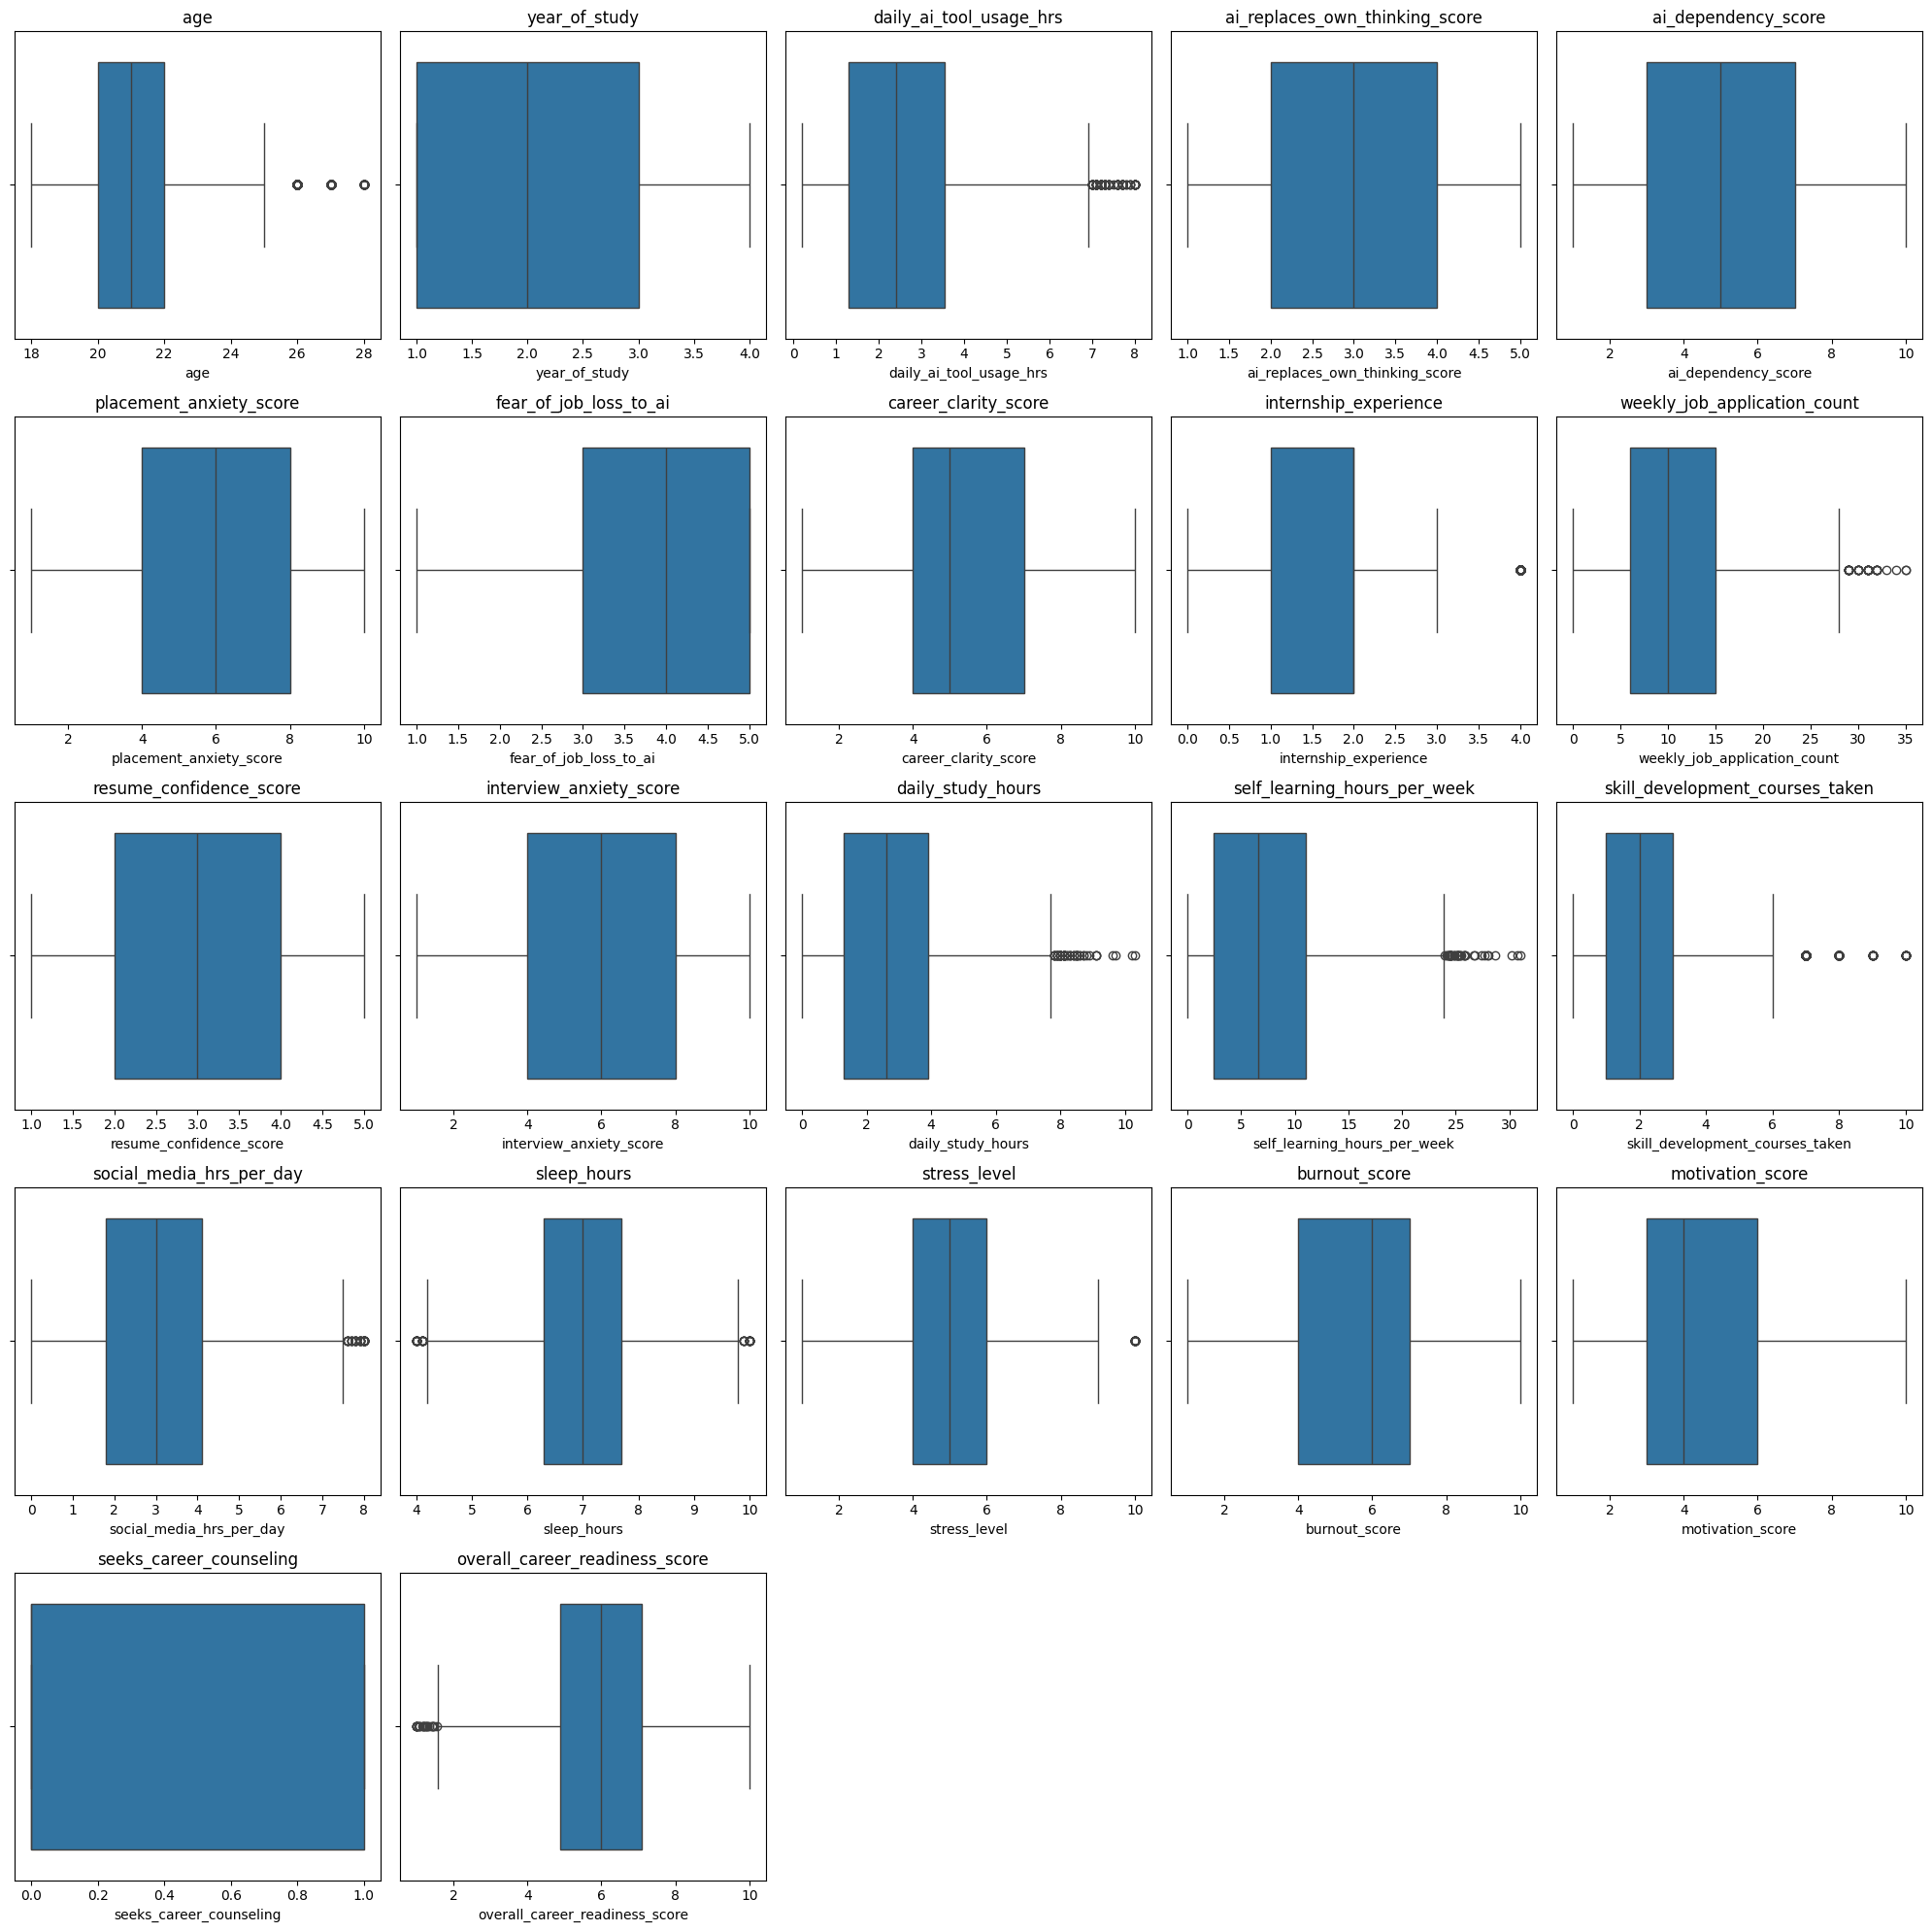

In [ ]:
plt.figure(figsize=(20,20))

for i in range(len(data_numerik)):
  plt.subplot(5,5,i+1)
  sns.boxplot(x=df_clean[data_numerik[i]])
  plt.title(data_numerik[i])
  plt.tight_layout()

khusus seeks_career_counseling pakai barplot krn datanya hanya ada 2 target (ya/tidak)

Text(0, 0.5, 'Count')

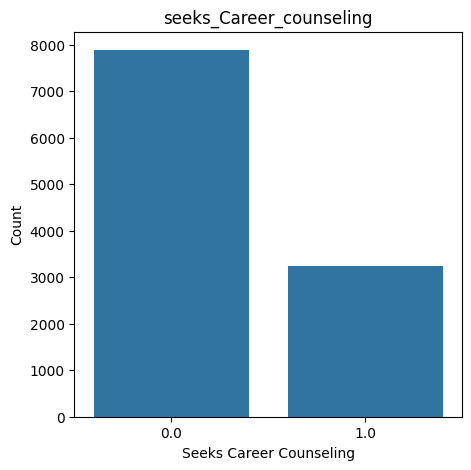

In [ ]:
plt.figure(figsize=(5,5))

sns.barplot(x=df_clean['seeks_career_counseling'].value_counts().index, y=df_clean['seeks_career_counseling'].value_counts().values)
plt.title('seeks_Career_counseling')
plt.xlabel('Seeks Career Counseling')
plt.ylabel('Count')



1.   `'Age'`: rata" berada di rentang 20 - 22 tahun, sebagian kecil outliers ada di umur 26 - 28 -> bisa jadi gap students, terlambat lulus
2.   'year_of_study': sebagian besar menempuh pendidikan di rentang 1- 4 tahun, normalnya pendidikan di perguruan tinggi -> no outliers

1.   'daily_ai_tools_usage_hrs' : rata" pakai ai selama 1 - 3.5 jam, sebagian kecil pakai selama 7-8 hours -> researcher atau students yang perlu lebih banyak brainstorming dgn ai

1.   'ai_replaces_own_thinking_score': rata" ada di skor 2-4, masih normal no outliers

1.   'ai_dependency_score': rata" ada di skor 3-7 -> majority students merasa ai bakal replaces their own skills

1.   'placement_anxiety_scores' : majority ada di skor 4-8 -> student merasa cemasnya terhadap penempatan kerja terhadap AI cukup tinggi

1.   'fear_job_loss_to_ai' : majority ada di skor 3 - 5 -> students sangat cemas dan takut akan kehilangnan pekerjaan yg digantikan AI

1.   'career_clarity_Score' : mostly ada di skor 4-7 -> banyak studs yg merasa arah karir mereka blm jelas -> domino effect krn replacable dgn AI

1.   'internship_experience' : sebagian besar hanya ada di skor 1 - 2 -> sebagian kecil studs yg experiencenya di skor 4 -> keadaan mengkhawatirkan pengalaman kerjasama studs di dunia kerja

1.   'weekly_job_application_count' : sebagian besar ada di skor 5 - 15 -> beberapa studs di angka > 30 -> sebagian besar studs blm aktif melamar pekerjaan, sebgaian aktif melamar pekerjaan hingga 30 job keatas

1.   'resume_confidence': rata" di skor 2 - 3.5 -> no outliers, styds merasa kurang percaya diri dgn resume nya

2.   'interview_anxiety_score': rata" di skor 4 - 8 -> indicate bahwa banyak studs yg merasa gugup dan kurang percaya diri ketika akan interview


2.   'daily_stud_hours' : majority di 1.5 - 4 jam -> sebagian ada yg > 8 jam -> bisa jadi studs yg perlu pemahaman dan konsentrasi belajar lebih lama dan lebih fokus, ambisius atau menjelang exam


2.   'self_learning_hours_per_week' : majority studs di angka 2,5 - 4 jam per minggu -> outliers dgn beberapa studs ada yg > 25 hours -> studs yg sangat ambisius dan ratin belajar intensif


2.   'skill_dev_courses_taken' : bbrp studs hanya mengambil 1-3 course untuk skill dev, cukup rendah -> beberapa studs (outlier) yg mengambil courses cukup tinggi dengan 7-10 courses -> bbrp studs bisa jadi sadar akan replacable skillnya oleh AI


2.   'social_media_per_day' : majority studs menghabiskan waktu 2-4 jam per hari untuk socmed (bisa jd untuk upskilling skill dan self learning) -> outlier dtuds dgn durasi > 8 jam -> produktivitas berkurang atau bs jadi berkorelasi dgn burnout


2.   'sleep_hours' : beberapa studs tidur dengan durasi normal 6 - 8 jam, beberapa studs ada yg kurang tidur dgn durasi < 4 jam -> kebanyakan belajar, burnout/stress tinggi, kebanyakan main socmed, dan studs yg tidur terlalu lama diatas normal dgn durasi 10 jam -> kelelahan belajar, produktivitas menurun


2.   'stress_level' : distribusi stress level majority medium di angka 4 - 6 -> bs jadi krn diimbangi main socmed untuk mengurangi tekanan, bbrp outlier studs dgn stress level 10 -> possibility berkorelasi dgn burnout, sleep hours


2.   'burnout_score' : rata" ada di angka 4 - 7 -> cukup serius, possibility untuk berkorelasi dgn daily_stud_hours, stress_lv


2.   'motivation_Score' : cukup rendah di angka 1.5 - 6 -> studs sangat tidak termotivasi dgn baik, possibility berkorelasi dgn ai_replaces, fear_of_job, anxiety, stress, dll


1.   seeks_career_counseling: sadly majority tdk berusaha mencari bimbingan career
2.   overall_readiness: 5-7 -> studs masih belum terlalu siap untuk berkarir -> beberapa ada yg tidak siap sama sekali dgn jumlah < 2







***Univariate Analysis***